##### Data downloads and set up

We will be using the 10X public dataset - PBMC-3K for our analysis. Link to download it: https://figshare.com/articles/dataset/PBMC_3k_dataset/30610988?file=59540234

Link for the Seurat tutorial: https://satijalab.org/seurat/articles/pbmc3k_tutorial.html

In [ ]:
# install.packages(c('dplyr', 'ggplot2', 'tidyr', 'reshape2'))

In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(reshape2)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.4.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [2]:
library(Seurat)
library(SingleCellExperiment)

Warning message:
"package 'Seurat' was built under R version 4.4.3"
Loading required package: SeuratObject

Warning message:
"package 'SeuratObject' was built under R version 4.4.3"
Loading required package: sp

Warning message:
"package 'sp' was built under R version 4.4.3"

Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats

Warning message:
"package 'matrixStats' was built under R version 4.4.3"

Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count



Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, col

#### PBMC 3K analysis

In [3]:
# Read the 10X data downloaded
pbmc_3k_data <- Read10X(data.dir = 'F:/scRNAseq_demo/pbmc_3k_data/filtered_gene_bc_matrices/hg19')
# Step 2: Create a Seurat object
pbmc_3k <- CreateSeuratObject(counts = pbmc_3k_data, project = "demo1")
str(pbmc_3k)

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:2286884] 70 166 178 326 363 410 412 492 494 495 ...
  .. .. .. .. .. .. ..@ p       : int [1:2701] 0 781 2133 3264 4224 4746 5528 6311 7101 7634 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 32738 2700
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:2286884] 1 1 2 1 1 1 1 41 1 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:2700, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. ..$ : 

In [4]:
pbmc_3k

An object of class Seurat 
32738 features across 2700 samples within 1 assay 
Active assay: RNA (32738 features, 0 variable features)
 1 layer present: counts

In [5]:
head(rownames(pbmc_3k), 10) # list of genes

[1] "MIR1302-10"    "FAM138A"       "OR4F5"         "RP11-34P13.7" 
 [5] "RP11-34P13.8"  "AL627309.1"    "RP11-34P13.14" "RP11-34P13.9" 
 [9] "AP006222.2"    "RP4-669L17.10"

In [6]:
head(colnames(pbmc_3k), 10) # cell barcodes

[1] "AAACATACAACCAC-1" "AAACATTGAGCTAC-1" "AAACATTGATCAGC-1" "AAACCGTGCTTCCG-1"
 [5] "AAACCGTGTATGCG-1" "AAACGCACTGGTAC-1" "AAACGCTGACCAGT-1" "AAACGCTGGTTCTT-1"
 [9] "AAACGCTGTAGCCA-1" "AAACGCTGTTTCTG-1"

#### SingleCellExperiment class

Basic object type for scRNAseq analysis.

Data (and metadata) is stored in various 'slots' and 'layers'.

Actual counts in the primary data layer (called 'assays').

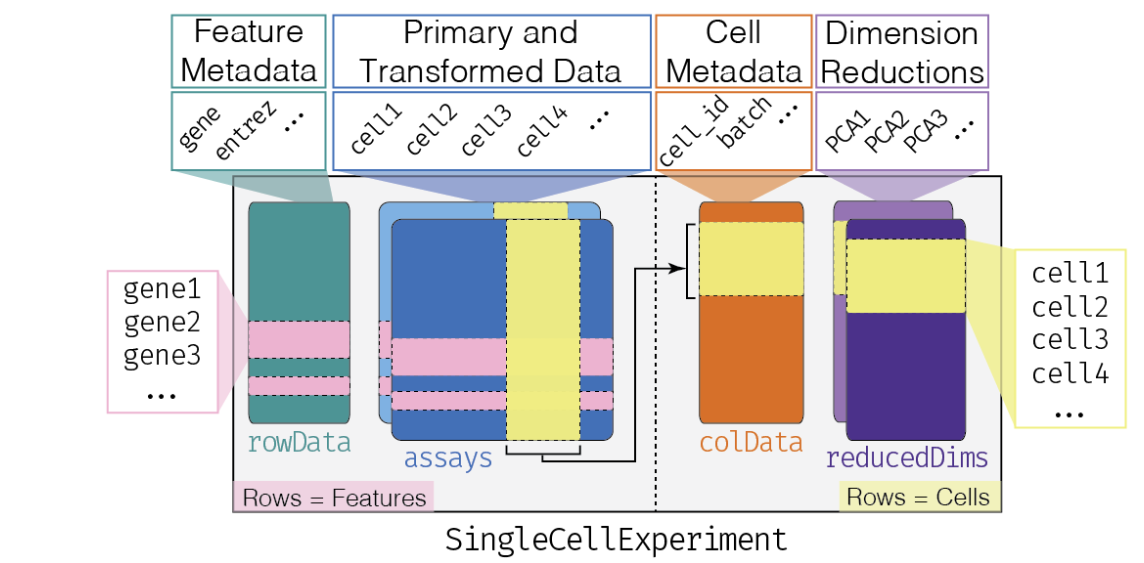

In [7]:
# view the counts matrix (5 rows and 5 cols)
pbmc_3k@assays$RNA@layers$counts[1:5,1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
              
[1,] . . . . .
[2,] . . . . .
[3,] . . . . .
[4,] . . . . .
[5,] . . . . .

#### Sparse matrices

Single-cell data is relatively sparse - most of the genes have no measurement recorded.

This is typically due to experimental procedures where many genes are not captured. However, as this 'missingness' is random, we can always proceed with our analysis.

#### Initial QC

In [ ]:
# BiocManager::install("scater")

In [8]:
library(scater)

Warning message:
"package 'scater' was built under R version 4.4.1"
Loading required package: scuttle



In [9]:
pbmc_3k[["percent.mt"]] <- PercentageFeatureSet(pbmc_3k, pattern = "^MT-")
pbmc_3k[["percent.ribo"]] <- PercentageFeatureSet(pbmc_3k, pattern = c("^RPL", "^RPS"))

Warning message in grep(pattern = pattern, x = rownames(x = object[[assay]][layer]), :
"argument 'pattern' has length > 1 and only the first element will be used"


In [10]:
pbmc_3k@meta.data$percent.mt[1:5] # percentage of mitochondrial genes per cell

[1] 3.0152829 3.7935958 0.8891712 1.7430845 1.2232416

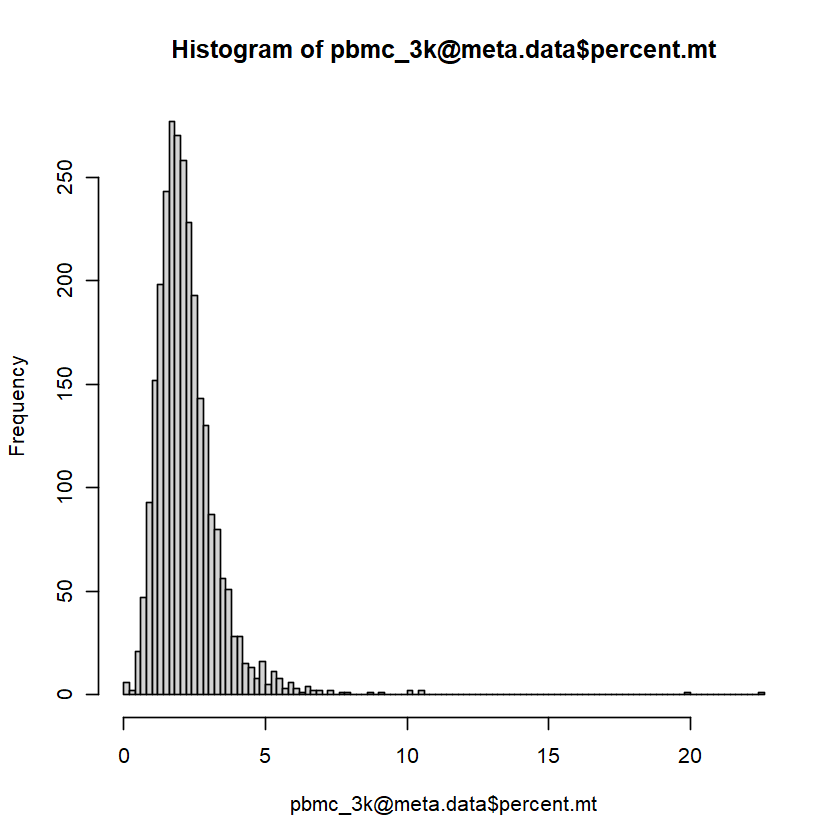

In [11]:
hist(pbmc_3k@meta.data$percent.mt, breaks = 100) # percentage of mitochondrial genes per cell

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."
Warning message:
"The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message:
"`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


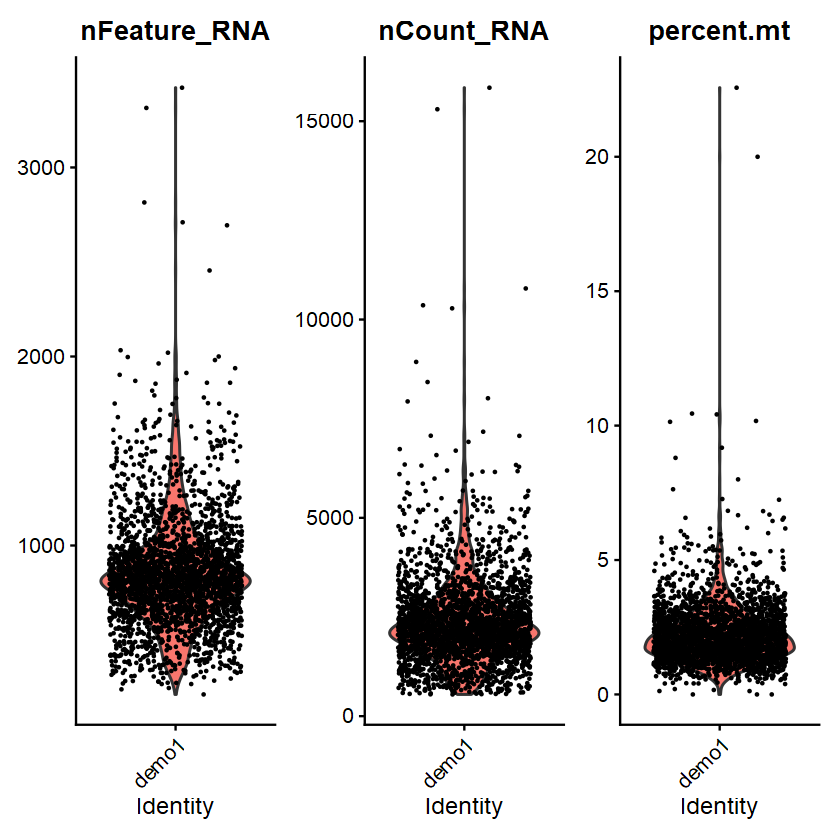

In [12]:
VlnPlot(pbmc_3k, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

##### QC thresholds

**** Strictly dependent on the dataset type *****

Good quality cells:  1. low mitochondrial gene content (expressed under stress or death)

                    2. Optimum number of genes (features) (typically between 200 to 2000)

Usual thresholds:  1. MT < 5%

                  2. #features ranging between 200 to 2000 (clearly the rest are outliers)

                  3. Gene to be expressed in a minimum of 10 cells (not a strict criteria)

In [13]:
table(pbmc_3k$percent.mt < 5)


FALSE  TRUE 
   57  2643 

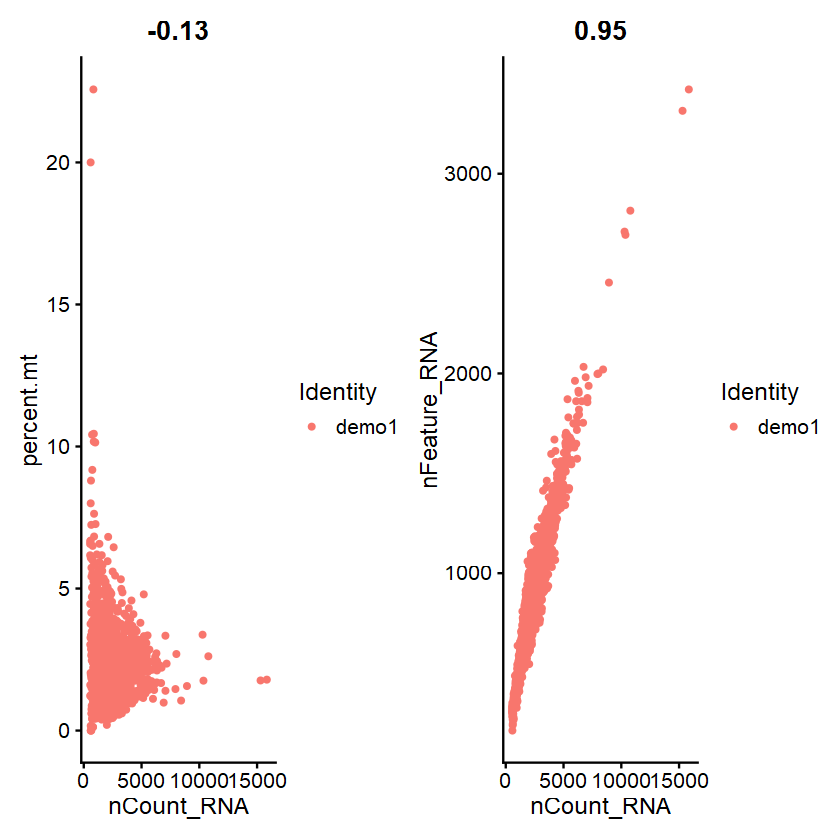

In [14]:
# scatter plots between two features
plot1 <- FeatureScatter(pbmc_3k, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(pbmc_3k, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [15]:
# filter the cells and features based on QC thresholds
pbmc_subset <- subset(pbmc_3k, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & percent.mt < 5)

In [16]:
pbmc_subset

An object of class Seurat 
32738 features across 2634 samples within 1 assay 
Active assay: RNA (32738 features, 0 variable features)
 1 layer present: counts

The above filtered data is based on composite QC metrics and is the input for subsequent steps. Note that we did not filter the genes that are expressed in very few cells. That filtering is achieved when we include only highly variable genes (HVGs).

##### Highly Variable Genes

Although the gene expression matrix is sparse, it is agreed that the missingness is truly random. Therefore, genes that are expressed at the same level in all cells (same baseline values) or rarely expressed will be dropped out. 

Rationale: Considering the most informative features for downstream analysis would simplify the computations and reduce any overfitting.

Typically 2000-3000 genes with high variance are selected. But first, are the gene counts comparable??

In [ ]:
# 20 random genes
set.seed(123)
# genes_to_plot <- sample(rownames(pbmc_subset), 1000)  # pick more, we’ll filter later

# Extract counts
# exp_subset <- FetchData(object = pbmc_subset, vars = genes_to_plot, layer = "counts")
exp_subset <- FetchData(object = pbmc_subset, layer = "counts", vars = rownames(pbmc_subset))
# Compute median expression per gene
gene_medians <- apply(exp_subset, 2, median)

# Filter genes with median > 5
genes_filtered <- names(gene_medians[gene_medians > 1.5])

# If very few pass, take top 10 by median
if (length(genes_filtered) > 20) {
  genes_filtered <- names(sort(gene_medians[genes_filtered], decreasing = TRUE))[1:20]
}

# Extract filtered expression data
exp_subset_filt <- exp_subset[, genes_filtered]

# Convert to long format
expr_long <- exp_subset_filt %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell") %>%
  pivot_longer(
    cols = -cell,
    names_to = "gene",
    values_to = "expression"
  )

# Plot
ggplot(expr_long, aes(x = gene, y = expression)) +
  geom_boxplot(outlier.shape = NA, fill = "lightblue") +
  theme_classic() +
  labs(
    title = "Expression of Highly Expressed Random Genes",
    x = "Gene",
    y = "Raw counts"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8)
  )


In [ ]:
length(genes_filtered)

#### Data normalization

In [ ]:
pbmc_norm <- NormalizeData(pbmc_subset,normalization.method = 'LogNormalize', scale.factor = 1e4)
pbmc_norm

In [ ]:
str(pbmc_norm)

In [ ]:
# 20 random genes
set.seed(123)
# genes_to_plot <- sample(rownames(pbmc_subset), 1000)  # pick more, we’ll filter later

# Extract counts
# exp_subset <- FetchData(object = pbmc_subset, vars = genes_to_plot, layer = "counts")
exp_subset <- FetchData(object = pbmc_norm, layer = "data", vars = genes_filtered)
# Compute median expression per gene
gene_medians <- apply(exp_subset, 2, median)

# Filter genes with median > 5
genes_filtered <- names(gene_medians[gene_medians > 1.5])

# If very few pass, take top 10 by median
if (length(genes_filtered) > 20) {
  genes_filtered <- names(sort(gene_medians[genes_filtered], decreasing = TRUE))[1:20]
}

# Extract filtered expression data
exp_subset_filt <- exp_subset[, genes_filtered]

# Convert to long format
expr_long <- exp_subset_filt %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell") %>%
  pivot_longer(
    cols = -cell,
    names_to = "gene",
    values_to = "expression"
  )

# Plot
ggplot(expr_long, aes(x = gene, y = expression)) +
  geom_boxplot(outlier.shape = NA, fill = "lightblue") +
  theme_classic() +
  labs(
    title = "Normalised Expression of Highly Expressed Genes",
    x = "Gene",
    y = "Log-normalised counts"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8)
  )


In [ ]:
saveRDS(pbmc_norm, file = 'pbmc3k_normalised.rds')

#### HVG detection and downstream analysis

In [ ]:
pbmc_norm <- FindVariableFeatures(pbmc_norm, selection.method = "vst", nfeatures = 2000)

VST - Variance Stabilising Transform.

After transformation, variance is independent of the mean expression level



In [ ]:
# View top 10 HVGs
top10 <- head(VariableFeatures(pbmc_norm), 10)

# Plot variable features
plot1 <- VariableFeaturePlot(pbmc_norm)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

In [ ]:
all.genes <- rownames(pbmc_norm)
pbmc_norm <- ScaleData(pbmc_norm, features = all.genes)
pbmc_norm


In [ ]:
pbmc_norm <- RunPCA(pbmc_norm, features = VariableFeatures(object = pbmc_norm))
ElbowPlot(pbmc_norm)

7-8 PCs can explain maximum variance in the data

In [ ]:
# find neighbors 
pbmc_norm <- FindNeighbors(pbmc_norm, dims = 1:8)

In [ ]:
pbmc_norm <- FindClusters(pbmc_norm, resolution = 0.5)

Alternatives to Louvain method is the Leiden algorithm, which can give stable and accurate clusters.

Read: https://doi.org/10.1038/s41598-019-41695-z for comparison between Louvain and Leiden algorithms

In [ ]:
pbmc_norm <- RunUMAP(pbmc_norm, dims = 1:8)
DimPlot(pbmc_norm, reduction = "umap")

In [ ]:
str(pbmc_norm)

In [ ]:
head(pbmc_norm@meta.data)

In [ ]:
DimPlot(pbmc_norm, reduction = "umap", group.by = 'seurat_clusters', label = TRUE, label.size = 8,
alpha = 0.3)

In [ ]:
pbmc_norm2 <- FindClusters(pbmc_norm, resolution = 0.5, algorithm = 4) # Leiden algorithm
DimPlot(pbmc_norm2, reduction = "umap", group.by = 'seurat_clusters', label = TRUE, label.size = 8,
alpha = 0.3)

In [ ]:
install.packages('mclust')

#### Comparing clustering using Adjusted Rand Index

counting pairs of samples:

1. Pairs that are in the same cluster in both methods → agreement

2. Pairs that are in different clusters in both → agreement

3. Pairs that are together in one method but apart in another → disagreement

In [ ]:
library(mclust)
ari <- adjustedRandIndex(pbmc_norm$seurat_clusters, pbmc_norm2$seurat_clusters) # louvain vs leiden
cat("Adjusted Rand Index (ARI):", ari, "\n")

ARI ~ 1 indicates consistent clustering between the methods.

All the cells were clustered into eight clusters. What params can influence the number of clusters?

Hint: Clustering step has a hyper-param called 'resolution'.

In [ ]:
# save the object
saveRDS(pbmc_norm, file = './pbmc_3k_data/pbmc_3k_clustered.rds')